
# Bank Loan Risk Analytics using Python

## Business Problem

While SQL and Power BI were used to monitor lending performance and portfolio KPIs, this analysis focuses on understanding borrower behavior and identifying factors associated with loan defaults.

### Objectives
1. Identify borrower segments that dominate the portfolio.
2. Determine which loan purposes exhibit the highest default risk.
3. Analyze state-level default patterns.
4. Evaluate the impact of employment length and home ownership on loan performance.
5. Identify variables associated with default risk.
6. Segment borrowers into risk groups.
7. Build a predictive model for loan default.


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

plt.rcParams["figure.figsize"] = (10,6)
sns.set_style("whitegrid")


## Load Dataset

In [2]:
df = pd.read_csv('financial_loan.csv')
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11-02-2021,13-09-2021,13-04-2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01-01-2021,14-12-2021,15-01-2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05-01-2021,12-12-2021,09-01-2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25-02-2021,12-12-2021,12-03-2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,01-01-2021,14-12-2021,15-01-2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


## Data Quality Assessment

In [20]:
print(df.shape)
display(df.info())
display(df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())

(38576, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38572 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  object        
 9   last_payment_date      38576 non-null  object        
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  object        
 12  member_id              38576 non-null  int64    

None

id                          0
address_state               0
application_type            0
emp_length                  0
emp_title                1438
grade                       0
home_ownership              0
issue_date                  4
last_credit_pull_date       0
last_payment_date           0
loan_status                 0
next_payment_date           0
member_id                   0
purpose                     0
sub_grade                   0
term                        0
verification_status         0
annual_income               0
dti                         0
installment                 0
int_rate                    0
loan_amount                 0
total_acc                   0
total_payment               0
default_flag                0
risk_score                  0
risk_segment                0
dtype: int64

Duplicate Rows: 0


The dataset contains 38,576 loan records and 27 variables. Missing value analysis revealed limited data quality issues, primarily within employment length, while no duplicate records were identified. Overall, the dataset was deemed suitable for further analysis and predictive modeling.

## Feature Engineering

In [4]:
df['default_flag'] = np.where(df['loan_status']=='Charged Off',1,0)

if 'issue_date' in df.columns:
    df['issue_date'] = pd.to_datetime(df['issue_date'], errors='coerce')

Key analytical features were created by converting loan default status into a binary target variable and transforming date fields into a format suitable for analysis and predictive modeling.

## Borrower and Loan Profile Analysis

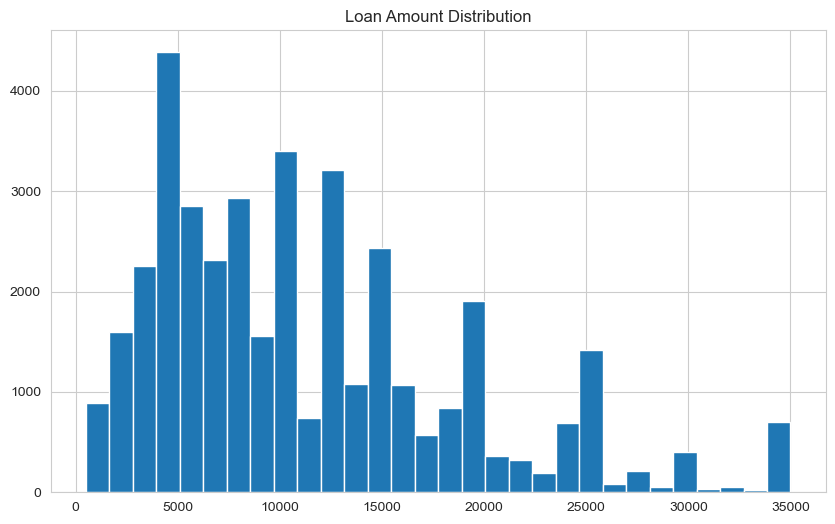

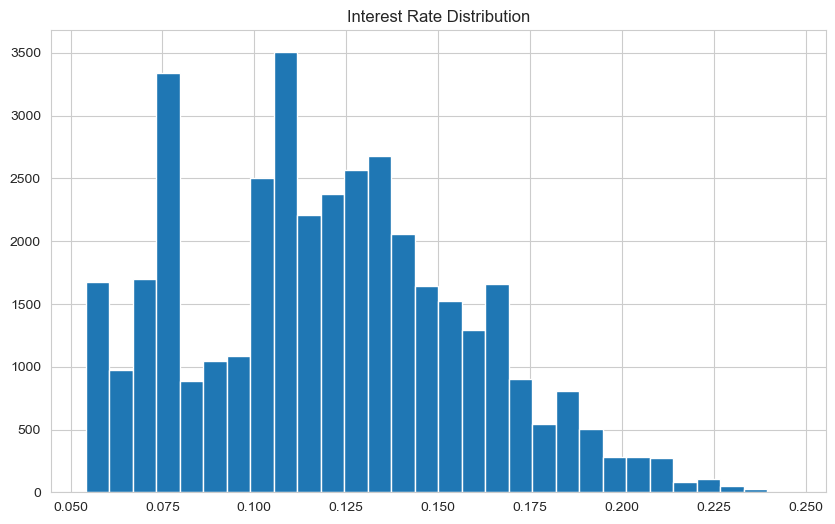

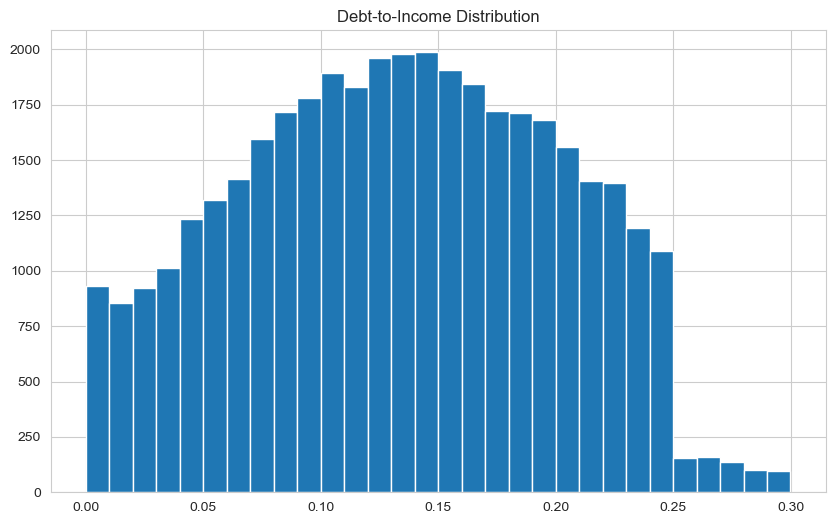

In [5]:
fig, ax = plt.subplots()
df['loan_amount'].hist(bins=30, ax=ax)
ax.set_title('Loan Amount Distribution')
plt.show()

fig, ax = plt.subplots()
df['int_rate'].hist(bins=30, ax=ax)
ax.set_title('Interest Rate Distribution')
plt.show()

fig, ax = plt.subplots()
df['dti'].hist(bins=30, ax=ax)
ax.set_title('Debt-to-Income Distribution')
plt.show()

Distribution analysis reveals the overall lending profile of the portfolio by examining loan amounts, interest rates, and borrower debt-to-income ratios, providing an initial view of borrower risk characteristics.

## Borrower Segment Analysis

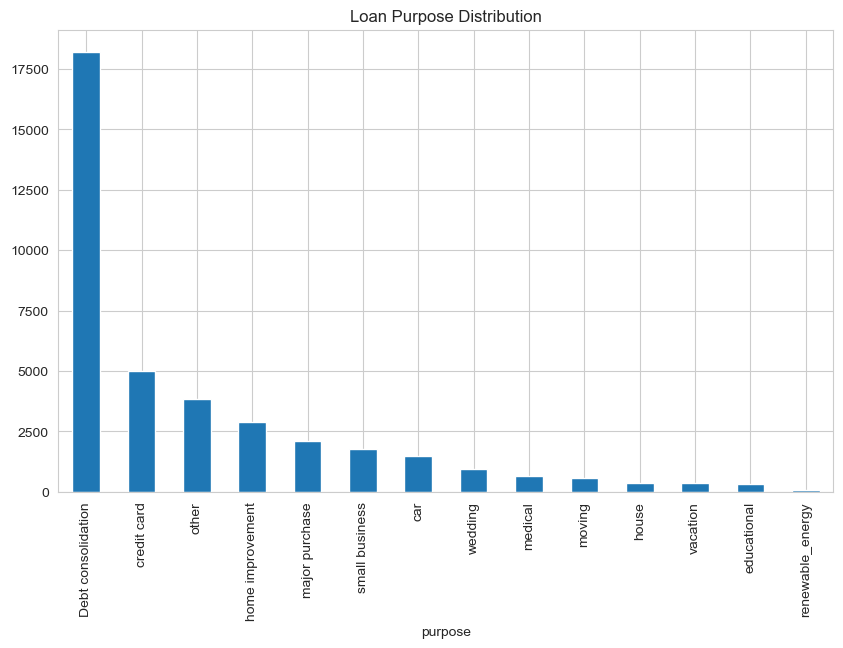

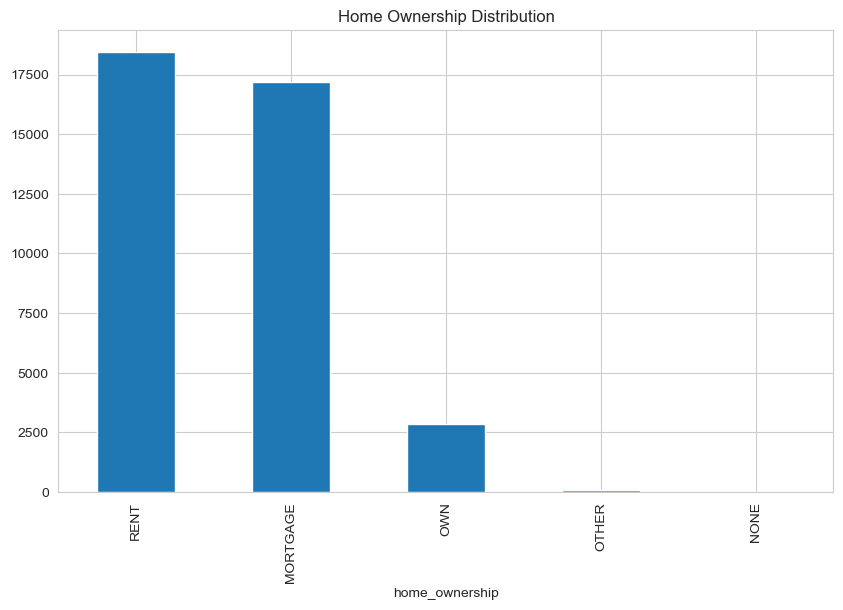

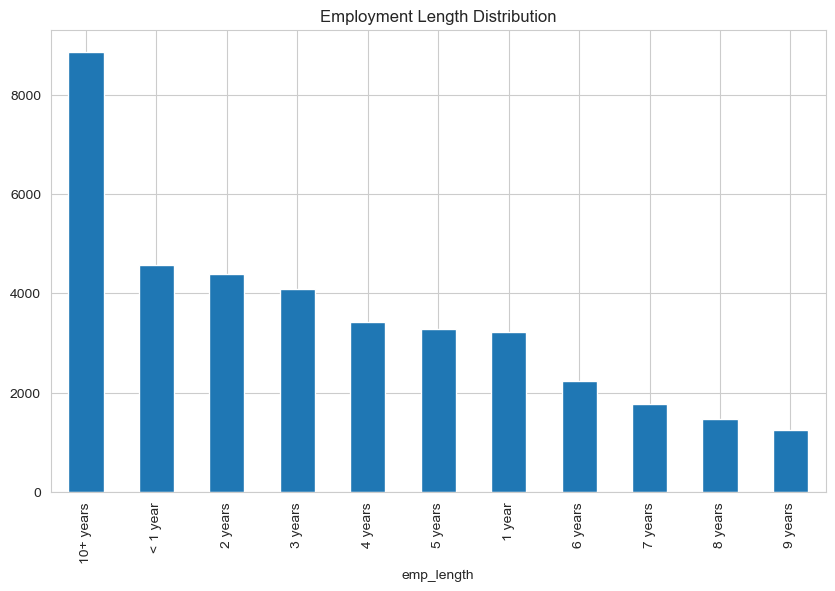

In [23]:
df['purpose'].value_counts().head(15).plot(kind='bar')
plt.title('Loan Purpose Distribution')
plt.show()

df['home_ownership'].value_counts().plot(kind='bar')
plt.title('Home Ownership Distribution')
plt.show()

df['emp_length'].value_counts().plot(kind='bar')
plt.title('Employment Length Distribution')
plt.show()

This analysis identifies the dominant borrower groups by examining loan purpose, home ownership status, and employment history, providing insights into the composition of the bank's customer base.

## Default Risk Analysis

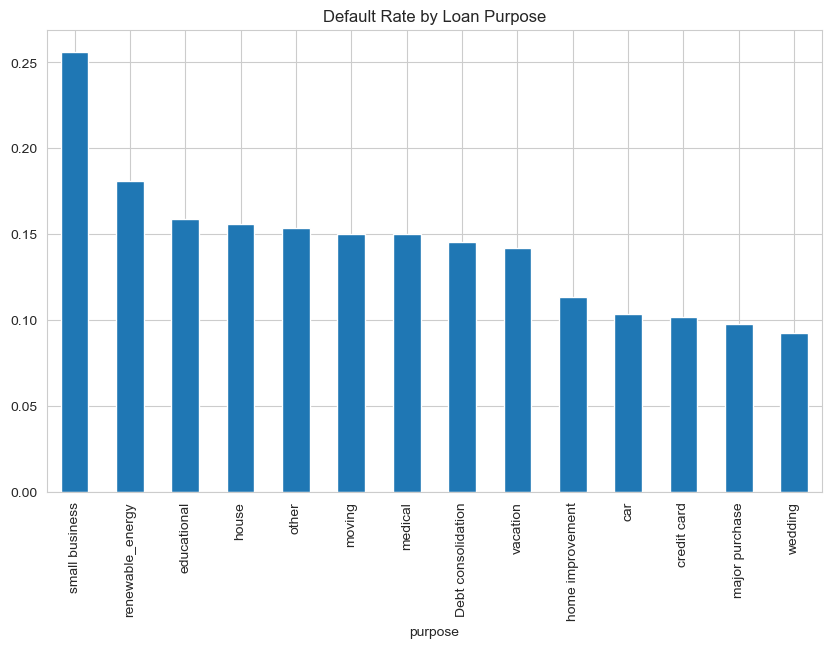

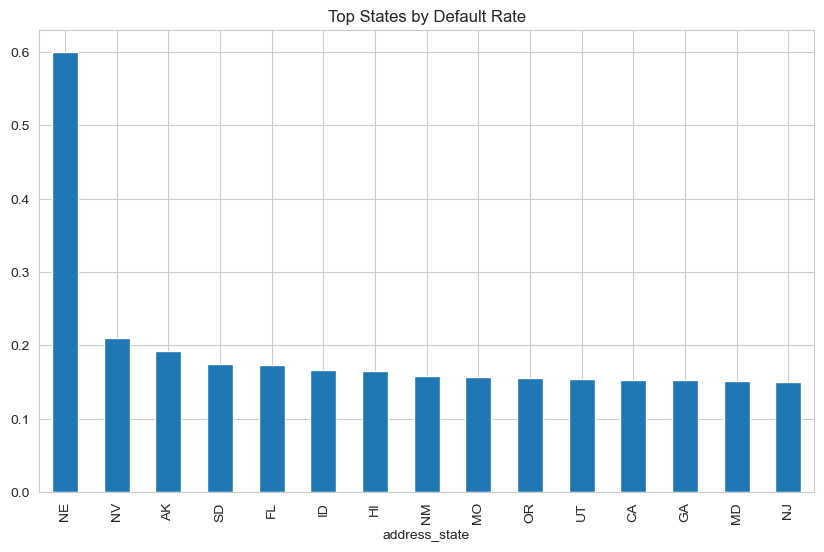

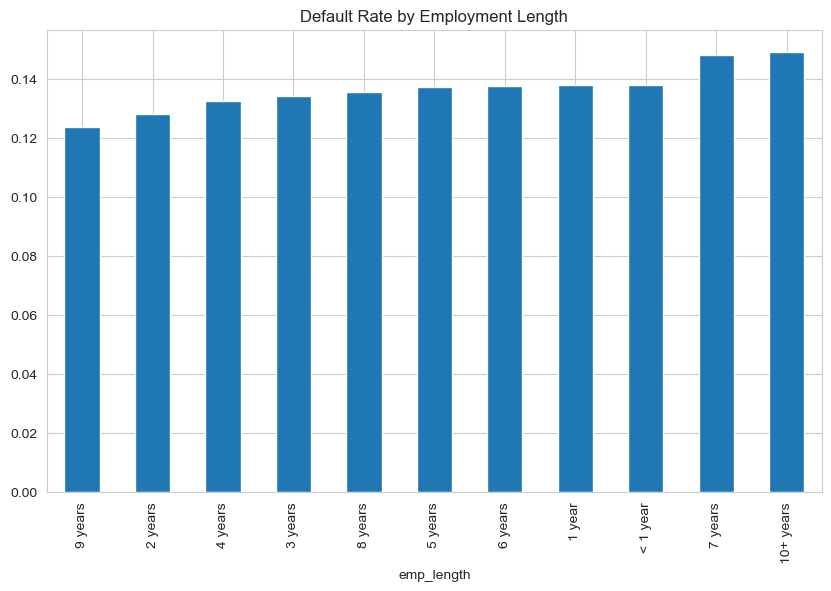

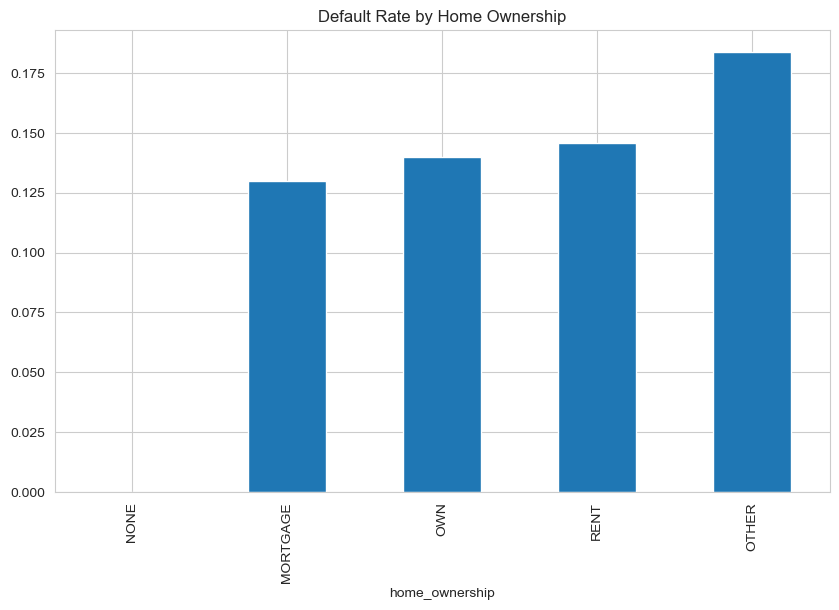

In [7]:

purpose_risk = df.groupby('purpose')['default_flag'].mean().sort_values(ascending=False)
purpose_risk.plot(kind='bar')
plt.title('Default Rate by Loan Purpose')
plt.show()

state_risk = df.groupby('address_state')['default_flag'].mean().sort_values(ascending=False).head(15)
state_risk.plot(kind='bar')
plt.title('Top States by Default Rate')
plt.show()

emp_risk = df.groupby('emp_length')['default_flag'].mean().sort_values()
emp_risk.plot(kind='bar')
plt.title('Default Rate by Employment Length')
plt.show()

home_risk = df.groupby('home_ownership')['default_flag'].mean().sort_values()
home_risk.plot(kind='bar')
plt.title('Default Rate by Home Ownership')
plt.show()


Default rates were analyzed across loan purposes, geographic regions, employment histories, and home ownership categories to identify the borrower characteristics most strongly associated with credit risk.

### Key Findings

• Small Business loans exhibit the highest default rates among all loan purposes.

• Default risk varies significantly across states, indicating regional differences in borrower behavior.

• Borrowers with shorter employment histories generally exhibit higher default rates.

• Home ownership status influences repayment performance, with some ownership categories displaying elevated credit risk.

These findings suggest that borrower characteristics can provide valuable information for risk assessment and lending decisions.

## Correlation Analysis

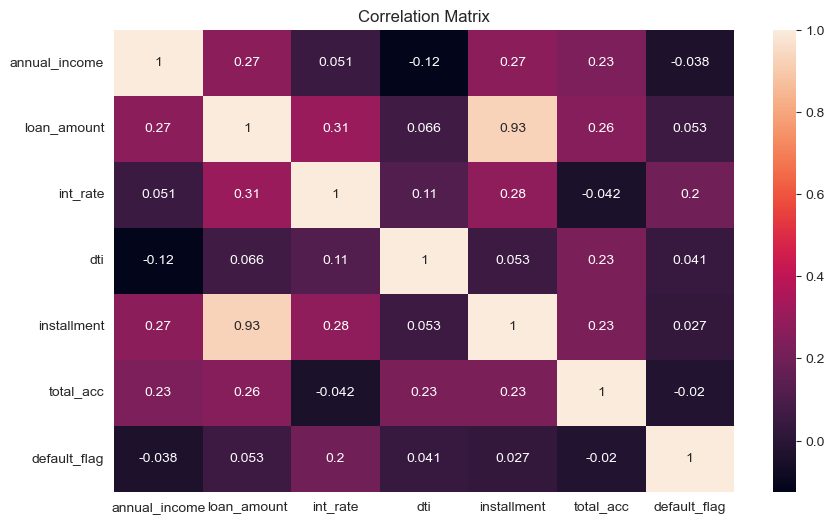

In [8]:

corr_cols = [
    'annual_income',
    'loan_amount',
    'int_rate',
    'dti',
    'installment',
    'total_acc',
    'default_flag'
]

corr = df[corr_cols].corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.title('Correlation Matrix')
plt.show()


The correlation matrix was used to examine relationships among borrower characteristics, loan attributes, and default behavior, helping identify variables that may influence credit risk.

### Key Findings

• Interest Rate exhibits the strongest positive relationship with loan default, suggesting higher-risk borrowers are charged higher rates.

• Debt-to-Income Ratio shows a positive relationship with default risk, indicating that highly leveraged borrowers are more likely to experience repayment difficulties.

• Loan Amount and Installment are strongly correlated, which is expected because larger loans generally require larger monthly payments.

• Correlation analysis provides preliminary evidence of risk drivers that will be examined further through predictive modeling.

## Risk Segmentation

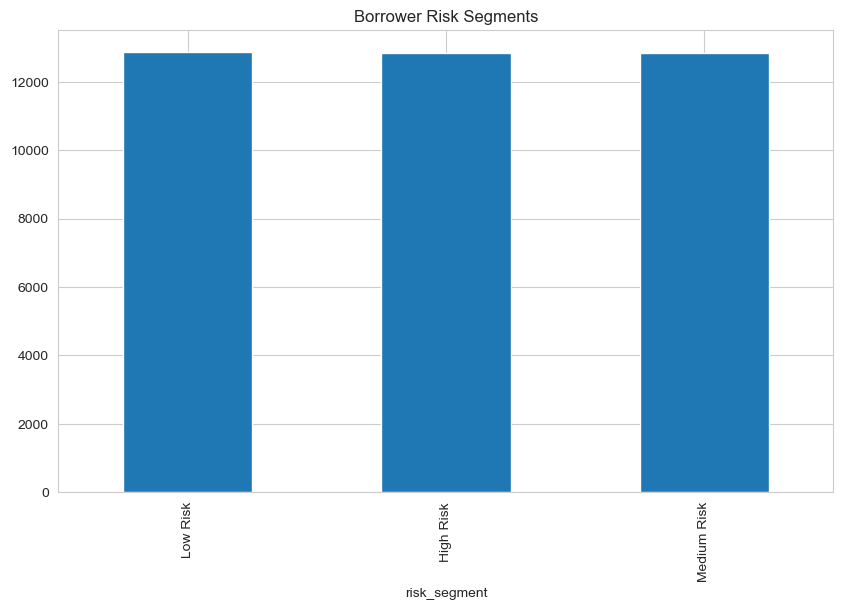

risk_segment
Low Risk       0.090817
Medium Risk    0.140389
High Risk      0.183600
Name: default_flag, dtype: float64

In [16]:

df['risk_score'] = (df['dti']*100) + (df['int_rate']*100)

df['risk_segment'] = pd.qcut(
    df['risk_score'],
    q=3,
    labels=['Low Risk','Medium Risk','High Risk']
)

df['risk_segment'].value_counts().plot(kind='bar')
plt.title('Borrower Risk Segments')
plt.show()

display(
    df.groupby(
        'risk_segment',
        observed=False
    )['default_flag'].mean()
)


Borrowers were classified into Low, Medium, and High Risk groups using a composite risk score, revealing a clear increase in default rates as borrower risk increases.

### Key Findings

• Low Risk borrowers exhibit a default rate of 9.1%.

• Medium Risk borrowers exhibit a default rate of 14.0%.

• High Risk borrowers exhibit a default rate of 18.4%.

• The High Risk segment defaults at approximately twice the rate of the Low Risk segment, indicating that the segmentation framework effectively distinguishes between low- and high-risk borrowers.

• These findings suggest that risk-based approval and pricing strategies could improve portfolio quality and reduce future credit losses.

## Predictive Modeling

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Features used for prediction
features = [
    'annual_income',
    'loan_amount',
    'int_rate',
    'dti',
    'installment',
    'total_acc'
]

# Define X and y
X = df[features]
y = df['default_flag']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Train Logistic Regression
model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
preds = model.predict(X_test)

# Prediction Probabilities
probs = model.predict_proba(X_test)[:,1]

# Evaluation Metrics
print("Accuracy:", round(accuracy_score(y_test, preds),4))

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        preds,
        zero_division=0
    )
)

print(
    "\nROC-AUC Score:",
    round(
        roc_auc_score(
            y_test,
            probs
        ),
        4
    )
)

Accuracy: 0.6322

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.63      0.75      6649
           1       0.22      0.64      0.33      1067

    accuracy                           0.63      7716
   macro avg       0.57      0.64      0.54      7716
weighted avg       0.82      0.63      0.69      7716


ROC-AUC Score: 0.6861


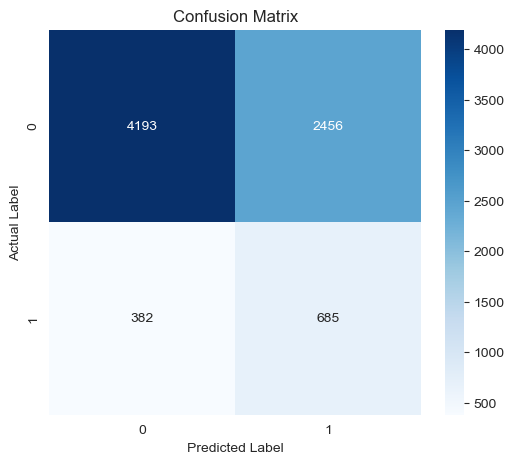

In [25]:
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

The confusion matrix evaluates the model's ability to distinguish between performing and defaulted loans, demonstrating its effectiveness in identifying high-risk borrowers.

### Key Findings

• The model correctly identified 685 defaulted borrowers and 4,193 performing borrowers.

• Approximately 64% of all defaults were successfully detected, indicating that the model captures a meaningful portion of credit risk.

• The ROC-AUC score of 0.69 suggests moderate predictive capability and confirms that borrower characteristics contain useful information for estimating default risk.

• While the model is not intended for production deployment, it demonstrates the feasibility of using borrower attributes to support risk assessment and lending decisions.

## Feature Importance

,Feature,Coefficient
2,int_rate,12.450545
3,dti,0.683409
1,loan_amount,0.000056
0,annual_income,-0.000005
5,total_acc,-0.000555
4,installment,-0.001787


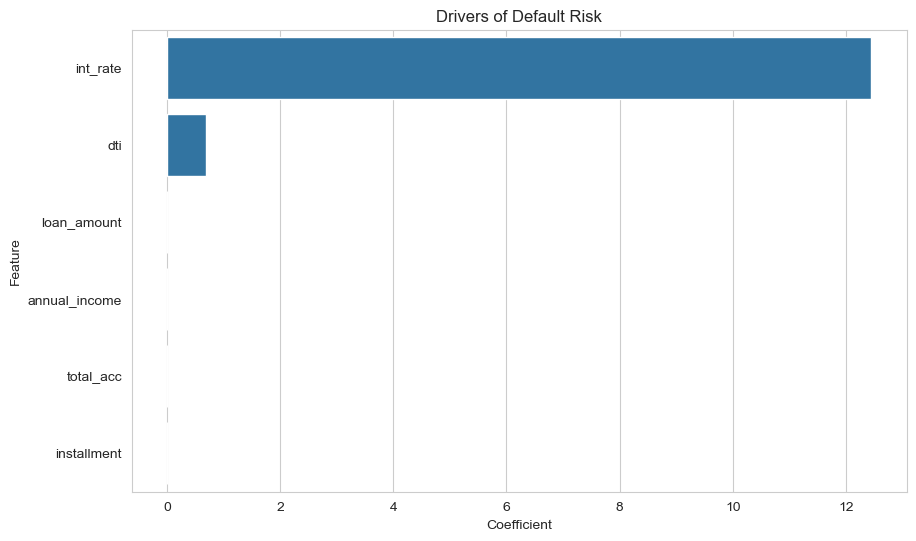

In [13]:

importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

display(importance)

sns.barplot(data=importance, x='Coefficient', y='Feature')
plt.title('Drivers of Default Risk')
plt.show()


Feature importance analysis identifies the borrower and loan characteristics that contribute most strongly to default prediction, helping explain the key drivers of credit risk.


# Business Recommendations

1. Strengthen underwriting for high-risk loan purposes.
2. Monitor high-default states more closely.
3. Apply enhanced screening for high DTI borrowers.
4. Use risk segmentation during loan approval.
5. Incorporate predictive scoring into lending decisions.
